In [ ]:
import os
import sys
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.api as sm
from pathlib import Path
from scipy.stats import spearmanr

_here = Path.cwd()
if not (_here / 'champ_analysis.ipynb').exists():
    for _c in [_here / 'priors' / 'promotion',
               _here / 'premier_league' / 'priors' / 'promotion',
               _here / 'non_penalty_bayes' / 'premier_league' / 'priors' / 'promotion',
               _here / 'team_strength' / 'non_penalty_bayes' / 'premier_league' / 'priors' / 'promotion']:
        if _c.exists():
            os.chdir(_c)
            break

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT    = str(NOTEBOOK_DIR.parents[6])
DB_PATH      = Path(REPO_ROOT) / 'infra' / 'data' / 'db' / 'fotmob.db'
OUT_DIR      = NOTEBOOK_DIR / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

# ── shared palette (one system, used consistently across every chart) ──────
C_XG        = '#2a78d6'   # xG series (categorical slot 1 / diverging "under" pole)
C_GOALS     = '#eb6834'   # goals series (categorical slot 2)
C_PRED      = '#1baf7a'   # predicted-as-its-own-series (categorical slot 3)
C_OVER      = '#e34948'   # over-prediction / positive bias / positive luck
C_UNDER     = '#2a78d6'   # under-prediction / negative bias / negative luck
C_GRID      = '#e1e0d9'
C_AXIS      = '#c3c2b7'
C_MUTED     = '#898781'
C_INK       = '#0b0b0b'
C_INK2      = '#52514e'

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'axes.edgecolor': C_AXIS,
    'axes.labelcolor': C_INK,
    'text.color': C_INK,
    'xtick.color': C_INK2,
    'ytick.color': C_INK2,
    'axes.grid': True,
    'grid.color': C_GRID,
    'grid.linewidth': 0.8,
    'axes.axisbelow': True,
})

In [2]:
# ── per-team-season, per-game non-penalty stats, straight from fotmob.db ───
# np_matches is already penalty-stripped for goals; match_stats' *_non_penalty
# xG columns give non-penalty xG directly. AVG() in SQL gives per-game rates
# in one pass instead of the sum-then-divide-by-matches_played dance the old
# champ_xg_history.csv / prem_xg_history.csv pipeline used.
TEAM_SEASON_STATS_QUERY = """
WITH team_games AS (
    SELECT
        m.season,
        m.league_id,
        m.home_team AS team_id,
        CAST(s.home_expected_goals_non_penalty AS REAL) AS xg,
        CAST(s.away_expected_goals_non_penalty AS REAL) AS xga,
        m.home_goals AS goals,
        m.away_goals AS goals_against,
        s.home_BallPossesion AS possession,
        s.home_touches_opp_box AS touches_opp_box
    FROM np_matches m
    JOIN match_stats s ON s.match_id = m.match_id
    WHERE m.league_id IN ('Championship', 'Premier_League')

    UNION ALL

    SELECT
        m.season,
        m.league_id,
        m.away_team AS team_id,
        CAST(s.away_expected_goals_non_penalty AS REAL) AS xg,
        CAST(s.home_expected_goals_non_penalty AS REAL) AS xga,
        m.away_goals AS goals,
        m.home_goals AS goals_against,
        s.away_BallPossesion AS possession,
        s.away_touches_opp_box AS touches_opp_box
    FROM np_matches m
    JOIN match_stats s ON s.match_id = m.match_id
    WHERE m.league_id IN ('Championship', 'Premier_League')
)
SELECT
    tg.season,
    tg.league_id,
    tg.team_id,
    tm.team_name                    AS team,
    COUNT(*)                        AS games,
    AVG(tg.xg)                      AS xg_per_game,
    AVG(tg.xga)                     AS xga_per_game,
    AVG(tg.goals)                   AS goals_per_game,
    AVG(tg.goals_against)           AS goals_against_per_game,
    AVG(tg.possession)              AS possession,
    AVG(tg.touches_opp_box)         AS touches_opp_box_per_game
FROM team_games tg
JOIN team_id_mapping tm ON tm.team_id = tg.team_id
GROUP BY tg.season, tg.league_id, tg.team_id
ORDER BY tg.season, tg.league_id, xg_per_game DESC
"""

with sqlite3.connect(DB_PATH) as conn:
    team_season_stats = pd.read_sql(TEAM_SEASON_STATS_QUERY, conn)

team_season_stats["season"] = team_season_stats["season"].str.replace("-", "/", regex=False)
for col in ["xg_per_game", "xga_per_game", "goals_per_game", "goals_against_per_game", "touches_opp_box_per_game"]:
    team_season_stats[col] = team_season_stats[col].round(3)
team_season_stats["possession"] = team_season_stats["possession"].round(1)

champ_perf = team_season_stats[team_season_stats["league_id"] == "Championship"].reset_index(drop=True)
prem_perf  = team_season_stats[team_season_stats["league_id"] == "Premier_League"].reset_index(drop=True)

champ_perf.head()

,season,league_id,team_id,team,games,xg_per_game,xga_per_game,goals_per_game,goals_against_per_game,possession,touches_opp_box_per_game
0,2020/2021,Championship,9850,Norwich,46,1.545,1.023,1.457,0.717,60.6,26.476
1,2020/2021,Championship,9937,Brentford,49,1.499,0.797,1.490,0.816,55.7,23.209
2,2020/2021,Championship,8655,Blackburn,46,1.383,1.108,1.304,1.087,57.5,22.907
3,2020/2021,Championship,8678,Bournemouth,48,1.344,1.053,1.500,0.917,57.3,21.860
4,2020/2021,Championship,9817,Watford,46,1.302,0.921,1.152,0.587,54.0,21.366


In [3]:
# ── prev-season metrics vs next-season scoring/conceding, per league ───────
# For each team-season, pull in that same team's goals-for/against rate the
# following season (within the same league — promoted/relegated teams simply
# drop out of the merge since they have no "next season" row in this league).
PREV_METRICS = [
    'xg_per_game', 'xga_per_game', 'goals_per_game',
    'goals_against_per_game', 'possession', 'touches_opp_box_per_game',
]
TARGET_MAP = {'goals_per_game': 'next_gf_per_game', 'goals_against_per_game': 'next_ga_per_game'}
TARGETS = list(TARGET_MAP.values())

def next_season_str(season: str) -> str:
    start, end = season.split('/')
    return f"{int(start) + 1}/{int(end) + 1}"

def build_prev_next_panel(league_df: pd.DataFrame) -> pd.DataFrame:
    d = league_df.copy()
    d['next_season'] = d['season'].apply(next_season_str)
    nxt = d[['season', 'team_id', 'goals_per_game', 'goals_against_per_game']].rename(columns=TARGET_MAP)
    merged = d.merge(
        nxt, left_on=['next_season', 'team_id'], right_on=['season', 'team_id'],
        suffixes=('', '_futrow'),
    )
    return merged[PREV_METRICS + TARGETS]

champ_panel = build_prev_next_panel(champ_perf)
prem_panel  = build_prev_next_panel(prem_perf)

print(f'champ_panel: {len(champ_panel)} team-season pairs')
print(f'prem_panel:  {len(prem_panel)} team-season pairs')

champ_panel: 105 team-season pairs
prem_panel:  85 team-season pairs


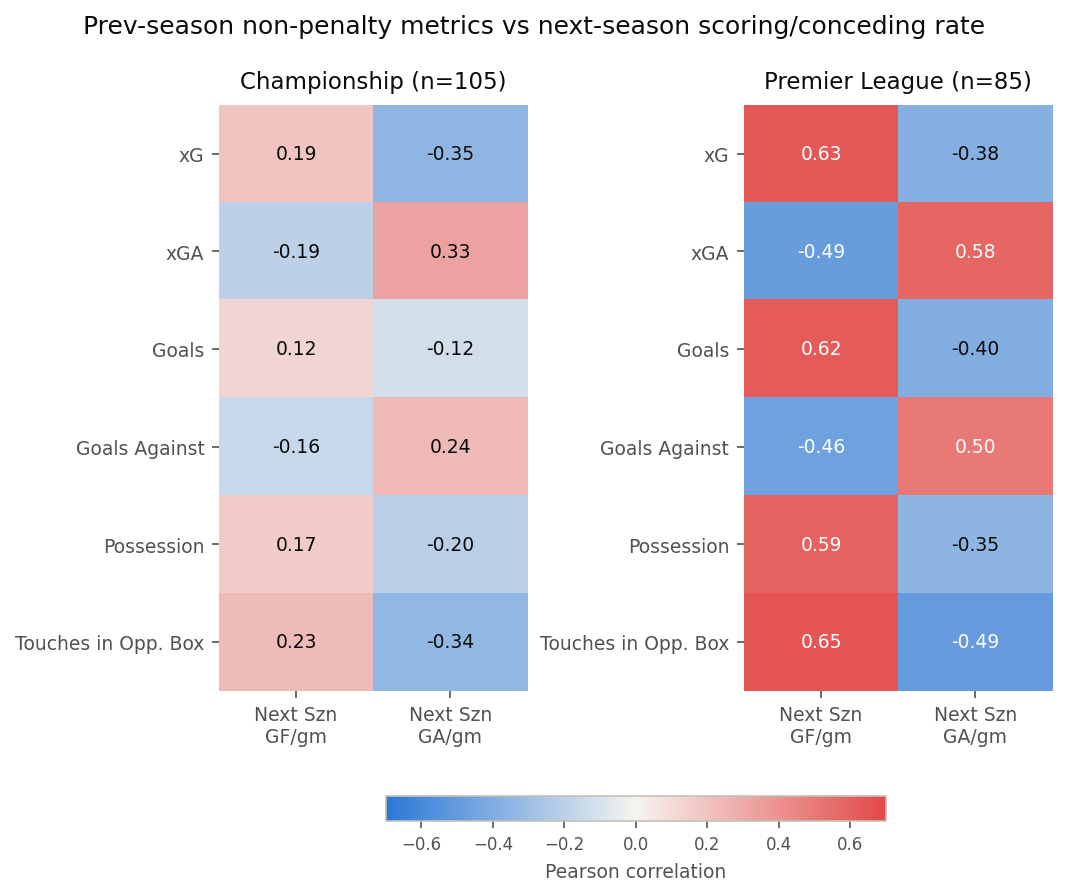

In [4]:
# ── correlation matrix: prev-season metrics vs next-season GF/GA rate ──────
from matplotlib.colors import LinearSegmentedColormap

METRIC_LABELS = {
    'xg_per_game': 'xG',
    'xga_per_game': 'xGA',
    'goals_per_game': 'Goals',
    'goals_against_per_game': 'Goals Against',
    'possession': 'Possession',
    'touches_opp_box_per_game': 'Touches in Opp. Box',
}
TARGET_LABELS = {
    'next_gf_per_game': 'Next Szn\nGF/gm',
    'next_ga_per_game': 'Next Szn\nGA/gm',
}

# diverging: C_UNDER (neg) -> neutral -> C_OVER (pos), validated pair (ΔE 32.3 normal, 21.6 protan)
DIVERGING_CMAP = LinearSegmentedColormap.from_list('corr_diverging', [C_UNDER, '#f5f4f0', C_OVER], N=256)

def corr_matrix(panel: pd.DataFrame) -> pd.DataFrame:
    return panel.corr().loc[PREV_METRICS, TARGETS]

champ_corr = corr_matrix(champ_panel)
prem_corr  = corr_matrix(prem_panel)

vmax = max(champ_corr.abs().max().max(), prem_corr.abs().max().max())
vmax = np.ceil(vmax * 10) / 10  # round up to nearest 0.1, shared scale so the two panels are comparable

fig, axes = plt.subplots(1, 2, figsize=(7, 5.5), constrained_layout=True)

for ax, corr, title, n in zip(
    axes, [champ_corr, prem_corr], ['Championship', 'Premier League'],
    [len(champ_panel), len(prem_panel)],
):
    im = ax.imshow(corr.values, cmap=DIVERGING_CMAP, vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(TARGETS)))
    ax.set_xticklabels([TARGET_LABELS[t] for t in TARGETS], fontsize=9)
    ax.set_yticks(range(len(PREV_METRICS)))
    ax.set_yticklabels([METRIC_LABELS[m] for m in PREV_METRICS], fontsize=9)
    ax.set_title(f'{title} (n={n})', fontsize=11, color=C_INK, pad=8)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            val = corr.values[i, j]
            text_color = 'white' if abs(val) > vmax * 0.6 else C_INK
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9, color=text_color)

cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.08, shrink=0.6)
cbar.set_label('Pearson correlation', fontsize=9, color=C_INK2)
cbar.ax.tick_params(labelsize=8, colors=C_INK2)

fig.suptitle('Prev-season non-penalty metrics vs next-season scoring/conceding rate', fontsize=12, color=C_INK, y=1.06)
plt.savefig(OUT_DIR / 'prev_season_corr_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# ── backward-elimination OLS: which prev-season metrics actually earn a spot ─
# Predictors are heavily collinear (xG/goals/touches-in-box/possession all
# track "team quality"), so start with all 6 and iteratively drop whichever
# has the weakest p-value until everyone left clears alpha. Features are
# z-scored first so the surviving coefficients are comparable in magnitude
# despite very different raw scales (xg_per_game ~1.5 vs possession ~55).
ALPHA = 0.05

def backward_select(panel: pd.DataFrame, target: str, candidates: list[str], alpha: float = ALPHA):
    X = panel[candidates].copy()
    X = (X - X.mean()) / X.std()
    y = panel[target]
    features = list(candidates)
    while True:
        Xc = sm.add_constant(X[features])
        model = sm.OLS(y, Xc).fit()
        pvals = model.pvalues.drop('const')
        worst_feature = pvals.idxmax()
        if pvals[worst_feature] <= alpha or len(features) == 1:
            return model, features
        features.remove(worst_feature)

REGRESSION_TARGETS = [('next_gf_per_game', 'Goals For'), ('next_ga_per_game', 'Goals Against')]
selection_summary = []

for league_name, panel in [('Championship', champ_panel), ('Premier League', prem_panel)]:
    for target_col, target_label in REGRESSION_TARGETS:
        full_X = sm.add_constant((panel[PREV_METRICS] - panel[PREV_METRICS].mean()) / panel[PREV_METRICS].std())
        full_model = sm.OLS(panel[target_col], full_X).fit()
        model, features = backward_select(panel, target_col, PREV_METRICS)

        print(f"\n{'=' * 72}\n{league_name} — next season {target_label} (n={len(panel)})\n{'=' * 72}")
        print(f"  full model (6 features):     R²={full_model.rsquared:.3f}  adj R²={full_model.rsquared_adj:.3f}")
        print(f"  backward-selected ({len(features)} feature{'s' if len(features) != 1 else ''}):  "
              f"R²={model.rsquared:.3f}  adj R²={model.rsquared_adj:.3f}")
        for name, coef, se, p in zip(model.params.index, model.params, model.bse, model.pvalues):
            print(f"    {name:>25}: {coef: .4f}  (se={se:.4f}, p={p:.3f})")

        selection_summary.append({
            'method': 'backward', 'league': league_name, 'target': target_label,
            'n': len(panel), 'features': ', '.join(f.replace('_per_game', '') for f in features),
            'r2': round(model.rsquared, 3), 'adj_r2': round(model.rsquared_adj, 3),
            'full_r2': round(full_model.rsquared, 3),
        })

selection_summary = pd.DataFrame(selection_summary)
selection_summary


Championship — next season Goals For (n=105)
  full model (6 features):     R²=0.071  adj R²=0.014
  backward-selected (1 feature):  R²=0.054  adj R²=0.045
                        const:  1.1920  (se=0.0383, p=0.000)
     touches_opp_box_per_game:  0.0937  (se=0.0385, p=0.017)

Championship — next season Goals Against (n=105)
  full model (6 features):     R²=0.190  adj R²=0.140
  backward-selected (2 features):  R²=0.165  adj R²=0.148
                        const:  1.2286  (se=0.0353, p=0.000)
                  xg_per_game: -0.1007  (se=0.0387, p=0.011)
                 xga_per_game:  0.0889  (se=0.0387, p=0.023)

Premier League — next season Goals For (n=85)
  full model (6 features):     R²=0.473  adj R²=0.433
  backward-selected (2 features):  R²=0.446  adj R²=0.432
                        const:  1.4300  (se=0.0322, p=0.000)
                 xga_per_game: -0.0774  (se=0.0383, p=0.047)
     touches_opp_box_per_game:  0.2135  (se=0.0383, p=0.000)

Premier League — next season Goal

,method,league,target,n,features,r2,adj_r2,full_r2
0,backward,Championship,Goals For,105,touches_opp_box,0.054,0.045,0.071
1,backward,Championship,Goals Against,105,"xg, xga",0.165,0.148,0.190
2,backward,Premier League,Goals For,85,"xga, touches_opp_box",0.446,0.432,0.473
3,backward,Premier League,Goals Against,85,"xga, touches_opp_box",0.380,0.365,0.421


In [6]:
# ── fixed 2-feature models: xG(A) + touches-in-box, same pair both leagues ─
# Simpler alternative to backward selection: lock in xg_per_game +
# touches_opp_box_per_game for goals scored, xga_per_game + touches_opp_box_per_game
# for goals conceded, and use the same pair for both Championship and Premier
# League so the comparison is apples-to-apples rather than league-tuned.
FIXED_FEATURES = {
    'Goals For': ['xg_per_game', 'touches_opp_box_per_game'],
    'Goals Against': ['xga_per_game', 'touches_opp_box_per_game'],
}

def fit_fixed(panel: pd.DataFrame, target: str, features: list[str]):
    X = panel[features].copy()
    X = (X - X.mean()) / X.std()
    Xc = sm.add_constant(X)
    return sm.OLS(panel[target], Xc).fit()

fixed_summary = []

for league_name, panel in [('Championship', champ_panel), ('Premier League', prem_panel)]:
    for target_col, target_label in REGRESSION_TARGETS:
        features = FIXED_FEATURES[target_label]
        model = fit_fixed(panel, target_col, features)

        print(f"\n{'=' * 72}\n{league_name} — next season {target_label} (n={len(panel)})\n{'=' * 72}")
        print(f"  fixed ({', '.join(features)}):  R²={model.rsquared:.3f}  adj R²={model.rsquared_adj:.3f}")
        for name, coef, se, p in zip(model.params.index, model.params, model.bse, model.pvalues):
            print(f"    {name:>25}: {coef: .4f}  (se={se:.4f}, p={p:.3f})")

        fixed_summary.append({
            'method': 'fixed', 'league': league_name, 'target': target_label,
            'n': len(panel), 'features': ', '.join(f.replace('_per_game', '') for f in features),
            'r2': round(model.rsquared, 3), 'adj_r2': round(model.rsquared_adj, 3),
            'full_r2': None,
        })

fixed_summary = pd.DataFrame(fixed_summary)

# ── side-by-side: backward-selected vs the fixed xG(A)+touches pair ────────
comparison = pd.concat([selection_summary, fixed_summary], ignore_index=True)
comparison = comparison.sort_values(['league', 'target', 'method']).reset_index(drop=True)
comparison


Championship — next season Goals For (n=105)
  fixed (xg_per_game, touches_opp_box_per_game):  R²=0.054  adj R²=0.036
                        const:  1.1920  (se=0.0385, p=0.000)
                  xg_per_game: -0.0050  (se=0.0717, p=0.945)
     touches_opp_box_per_game:  0.0980  (se=0.0717, p=0.175)

Championship — next season Goals Against (n=105)
  fixed (xga_per_game, touches_opp_box_per_game):  R²=0.160  adj R²=0.143
                        const:  1.2286  (se=0.0354, p=0.000)
                 xga_per_game:  0.0892  (se=0.0390, p=0.024)
     touches_opp_box_per_game: -0.0968  (se=0.0390, p=0.015)

Premier League — next season Goals For (n=85)
  fixed (xg_per_game, touches_opp_box_per_game):  R²=0.432  adj R²=0.418
                        const:  1.4300  (se=0.0326, p=0.000)
                  xg_per_game:  0.1062  (se=0.0756, p=0.164)
     touches_opp_box_per_game:  0.1592  (se=0.0756, p=0.038)

Premier League — next season Goals Against (n=85)
  fixed (xga_per_game, touches_opp_bo

,method,league,target,n,features,r2,adj_r2,full_r2
0,backward,Championship,Goals Against,105,"xg, xga",0.165,0.148,0.19
1,fixed,Championship,Goals Against,105,"xga, touches_opp_box",0.160,0.143,None
2,backward,Championship,Goals For,105,touches_opp_box,0.054,0.045,0.071
3,fixed,Championship,Goals For,105,"xg, touches_opp_box",0.054,0.036,None
4,backward,Premier League,Goals Against,85,"xga, touches_opp_box",0.380,0.365,0.421
5,fixed,Premier League,Goals Against,85,"xga, touches_opp_box",0.380,0.365,None
6,backward,Premier League,Goals For,85,"xga, touches_opp_box",0.446,0.432,0.473
7,fixed,Premier League,Goals For,85,"xg, touches_opp_box",0.432,0.418,None


In [ ]:
# ── promotion effect: Championship-trained prediction vs actual PL output ──
# champ_panel only contains team-seasons that stayed in the Championship the
# following year, so it never leaks a promoted team's PL numbers into the fit.
# Fit the same fixed xG(A)+touches models on champ_panel, then apply them to
# each promoted team's final Championship season to get "what this team would
# have been predicted to do had they stayed in the Championship." Comparing
# that to what they actually did in their first PL season isolates the
# step-up-in-quality effect from ordinary year-to-year regression to the mean.

def fit_with_scaler(panel: pd.DataFrame, target: str, features: list[str]):
    mu, sigma = panel[features].mean(), panel[features].std()
    Xc = sm.add_constant((panel[features] - mu) / sigma)
    model = sm.OLS(panel[target], Xc).fit()
    return model, mu, sigma

def predict_with_scaler(model, mu, sigma, frame: pd.DataFrame, features: list[str]):
    Xc = sm.add_constant((frame[features] - mu) / sigma, has_constant='add')
    return model.predict(Xc)

champ_gf_model, gf_mu, gf_sigma = fit_with_scaler(champ_panel, 'next_gf_per_game', FIXED_FEATURES['Goals For'])
champ_ga_model, ga_mu, ga_sigma = fit_with_scaler(champ_panel, 'next_ga_per_game', FIXED_FEATURES['Goals Against'])

# promoted team-seasons: champ team-season whose *next* season shows up in prem_perf instead of champ_perf
d = champ_perf.copy()
d['next_season'] = d['season'].apply(next_season_str)
prem_next = prem_perf[['season', 'team_id', 'goals_per_game', 'goals_against_per_game']].rename(
    columns={'goals_per_game': 'actual_pl_gf', 'goals_against_per_game': 'actual_pl_ga', 'season': 'pl_season'}
)
promotion_panel = d.merge(prem_next, left_on=['next_season', 'team_id'], right_on=['pl_season', 'team_id'])

promotion_panel['pred_champ_gf'] = predict_with_scaler(champ_gf_model, gf_mu, gf_sigma, promotion_panel, FIXED_FEATURES['Goals For'])
promotion_panel['pred_champ_ga'] = predict_with_scaler(champ_ga_model, ga_mu, ga_sigma, promotion_panel, FIXED_FEATURES['Goals Against'])
promotion_panel['gf_gap'] = promotion_panel['actual_pl_gf'] - promotion_panel['pred_champ_gf']
promotion_panel['ga_gap'] = promotion_panel['actual_pl_ga'] - promotion_panel['pred_champ_ga']

print(f"{len(promotion_panel)} promoted team-seasons\n")
print(promotion_panel[[
    'team', 'season', 'pl_season', 'pred_champ_gf', 'actual_pl_gf', 'gf_gap',
    'pred_champ_ga', 'actual_pl_ga', 'ga_gap',
]].round(3).to_string(index=False))

gf_gap_mean, gf_gap_std = promotion_panel['gf_gap'].mean(), promotion_panel['gf_gap'].std()
ga_gap_mean, ga_gap_std = promotion_panel['ga_gap'].mean(), promotion_panel['ga_gap'].std()
n_promoted = len(promotion_panel)

print(f"\n{'=' * 72}\nPROMOTION EFFECT (n={n_promoted} promoted team-seasons)\n{'=' * 72}")
print(f"  goals scored:    {gf_gap_mean:+.3f}/game (sd={gf_gap_std:.3f})  →  {gf_gap_mean * 38:+.1f} over a 38-game PL season")
print(f"  goals conceded:  {ga_gap_mean:+.3f}/game (sd={ga_gap_std:.3f})  →  {ga_gap_mean * 38:+.1f} over a 38-game PL season")
print(f"  {(promotion_panel['gf_gap'] < 0).sum()}/{n_promoted} promoted teams scored below their Championship-model prediction")
print(f"  {(promotion_panel['ga_gap'] > 0).sum()}/{n_promoted} promoted teams conceded above their Championship-model prediction")

In [ ]:
# ── forecast: Hull, Coventry, Ipswich PL totals next season ────────────────
# Same pipeline as the promotion-effect check above: run each team's most
# recent Championship season through the Championship-trained model, then
# add the average promotion effect (gf_gap_mean / ga_gap_mean, computed two
# cells up from the 15 historical promotions) to translate "predicted next
# Championship season" into "predicted first PL season."
PROMOTION_CANDIDATES = ['Hull', 'Coventry', 'Ipswich']

latest_champ = (
    champ_perf[champ_perf['team'].isin(PROMOTION_CANDIDATES)]
    .sort_values('season')
    .groupby('team', as_index=False)
    .tail(1)
    .reset_index(drop=True)
)

latest_champ['pred_champ_gf'] = predict_with_scaler(champ_gf_model, gf_mu, gf_sigma, latest_champ, FIXED_FEATURES['Goals For'])
latest_champ['pred_champ_ga'] = predict_with_scaler(champ_ga_model, ga_mu, ga_sigma, latest_champ, FIXED_FEATURES['Goals Against'])

latest_champ['pred_pl_gf_per_game'] = latest_champ['pred_champ_gf'] + gf_gap_mean
latest_champ['pred_pl_ga_per_game'] = latest_champ['pred_champ_ga'] + ga_gap_mean
latest_champ['pred_pl_gf_season'] = latest_champ['pred_pl_gf_per_game'] * 38
latest_champ['pred_pl_ga_season'] = latest_champ['pred_pl_ga_per_game'] * 38
latest_champ['pred_pl_gd_season'] = latest_champ['pred_pl_gf_season'] - latest_champ['pred_pl_ga_season']

# ± 1 sd band using the spread of the promotion effect itself (n=15, so treat as rough)
latest_champ['pred_pl_gf_season_lo'] = (latest_champ['pred_pl_gf_per_game'] - gf_gap_std) * 38
latest_champ['pred_pl_gf_season_hi'] = (latest_champ['pred_pl_gf_per_game'] + gf_gap_std) * 38
latest_champ['pred_pl_ga_season_lo'] = (latest_champ['pred_pl_ga_per_game'] - ga_gap_std) * 38
latest_champ['pred_pl_ga_season_hi'] = (latest_champ['pred_pl_ga_per_game'] + ga_gap_std) * 38

print(f"based on each team's {dict(zip(latest_champ['team'], latest_champ['season']))} Championship form\n")
for _, row in latest_champ.sort_values('pred_pl_gd_season', ascending=False).iterrows():
    print(f"{row['team']:>10}  GF {row['pred_pl_gf_season']:5.1f}  (±1sd {row['pred_pl_gf_season_lo']:.0f}-{row['pred_pl_gf_season_hi']:.0f})"
          f"   GA {row['pred_pl_ga_season']:5.1f}  (±1sd {row['pred_pl_ga_season_lo']:.0f}-{row['pred_pl_ga_season_hi']:.0f})"
          f"   GD {row['pred_pl_gd_season']:+6.1f}")

latest_champ[['team', 'season', 'pred_pl_gf_season', 'pred_pl_ga_season', 'pred_pl_gd_season']].round(1)

- do regression for xG and poss for next season goals and conceded (champ and prem)
- find the difference between expected poitns and actual
- explore adding the possession adjustment from John Knight